In [2]:
import tensorflow as tf
from tensorflow import keras 
from keras.models import Sequential
from keras.layers import Flatten, Dense
from keras.applications.mobilenet_v2 import MobileNetV2
from keras.layers import Rescaling

2025-04-01 21:18:18.938580: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-01 21:18:18.949467: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-01 21:18:19.048159: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-01 21:18:19.130487: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743522499.205068  101958 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743522499.23

In [8]:
conv_base = MobileNetV2(
    include_top = False,
    weights = 'imagenet',
    input_shape = (96,96,3)
)

In [9]:
leaf_model = Sequential([
    Rescaling(1./127.5, offset=-1, input_shape=(96, 96, 3)),  # Add this
    conv_base,
    Flatten(),
    Dense(1, activation='sigmoid')
])

/home/akshat-ranjan/anaconda3/lib/python3.12/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
leaf_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 11520)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        11,521 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,505 (8.66 MB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
conv_base.trainable = False

In [4]:
dataset = keras.preprocessing.image_dataset_from_directory(
    directory='./Dataset',
    shuffle=True,
    batch_size=32,
    image_size=(96, 96),  # Resize all images to 96x96
    interpolation='bilinear'  # Use bilinear interpolation for smooth resizing
)


Found 70817 files belonging to 2 classes.


In [5]:
leaf_class_names = dataset.class_names

In [6]:
leaf_class_names

['Leaf', 'Not Leaf']

In [7]:
dataset.cardinality().numpy()

2214

In [8]:
train_ds = dataset.take(int(len(dataset)*0.7))
valid_ds = dataset.skip(int(len(dataset)*0.7)).take(int(len(dataset)*0.2))
test_ds = dataset.skip(int(len(dataset)*0.9)).take(int(len(dataset)*0.1))

In [19]:
import numpy as np
y_train_labels = np.concatenate([y.numpy() for _, y in train_ds])
unique, counts = np.unique(y_train_labels, return_counts=True)
print("Class Distribution: ", dict(zip(unique, counts)))

Class Distribution:  {0: 45016, 1: 4552}


2025-04-01 19:17:45.165370: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [9]:
print(train_ds.cardinality())
print(valid_ds.cardinality())
print(test_ds.cardinality())

tf.Tensor(1549, shape=(), dtype=int64)
tf.Tensor(442, shape=(), dtype=int64)
tf.Tensor(221, shape=(), dtype=int64)


In [10]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(buffer_size=1000).prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [22]:
leaf_model.compile(
    optimizer = 'adam',
    metrics = ['accuracy'],
    loss = 'binary_crossentropy'
)

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', save_best_only=True)
]

In [24]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
import numpy as np
classes = np.array([0, 1])
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_labels)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {i: class_weights[i] for i in range(len(classes))}
print("Class Weights:", class_weight_dict)

Class Weights: {0: 0.5505598009596588, 1: 5.444639718804921}


In [25]:
history = leaf_model.fit(
    train_ds,
    validation_data = valid_ds,
    epochs = 50,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 1/50


2025-04-01 19:18:41.650701: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:14: Filling up shuffle buffer (this may take a while): 358 of 1000
2025-04-01 19:18:51.674487: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:14: Filling up shuffle buffer (this may take a while): 680 of 1000
2025-04-01 19:19:02.267004: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


1549/1549 ━━━━━━━━━━━━━━━━━━━━ 248s 138ms/step - accuracy: 0.9905 - loss: 0.0370 - val_accuracy: 0.9963 - val_loss: 0.0278
Epoch 2/50
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 139s 90ms/step - accuracy: 0.9974 - loss: 0.0143 - val_accuracy: 0.9981 - val_loss: 0.0135
Epoch 3/50
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 139s 90ms/step - accuracy: 0.9988 - loss: 0.0064 - val_accuracy: 0.9982 - val_loss: 0.0144
Epoch 4/50
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 139s 90ms/step - accuracy: 0.9989 - loss: 0.0060 - val_accuracy: 0.9987 - val_loss: 0.0133
Epoch 5/50
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 140s 90ms/step - accuracy: 0.9999 - loss: 4.5610e-04 - val_accuracy: 0.9987 - val_loss: 0.0147
Epoch 6/50
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 140s 91ms/step - accuracy: 0.9992 - loss: 0.0046 - val_accuracy: 0.9984 - val_loss: 0.0242
Epoch 7/50
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 141s 91ms/step - accuracy: 0.9990 - loss: 0.0097 - val_accuracy: 0.9982 - val_loss: 0.0301
Epoch 8/50
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 147s 95ms/step - accuracy: 0.9997

In [26]:
leaf_model.save('../saved_models/leaf_model.keras')

In [29]:
leaf_model.evaluate(test_ds)

221/221 ━━━━━━━━━━━━━━━━━━━━ 90s 95ms/step - accuracy: 0.9914 - loss: 0.0384


[0.047345492988824844, 0.9896776080131531]

In [3]:
leaf_model = keras.models.load_model('../saved_models/leaf_model.keras')

2025-04-01 21:18:29.767672: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
[8.7283095e-32]
Actual label:  Leaf
Predicted label:  Leaf


/tmp/ipykernel_101958/4229795314.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Predicted label: ", leaf_class_names[int(np.round(batch_pred[0]))])


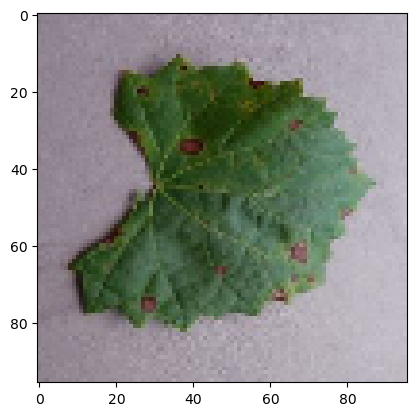

In [97]:
import numpy as np
import matplotlib.pyplot as plt

for image_batch, label_batch in test_ds.shuffle(buffer_size=1000).take(1):
    image = image_batch[0].numpy().astype('uint8')
    label = label_batch[0]

    plt.imshow(image)

    batch_pred = leaf_model.predict(image_batch)
    print(batch_pred[0])
    print("Actual label: ",leaf_class_names[label])
    print("Predicted label: ", leaf_class_names[int(np.round(batch_pred[0]))])

In [100]:
image_path = "/home/akshat-ranjan/Desktop/KrishE Project/KrishE/DL/Dataset/Not Leaf/image71.jpg"
image = keras.preprocessing.image.load_img(image_path, target_size=(96, 96))
leaf_model.predict(
    np.expand_dims(image, axis=0)
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


array([[1.]], dtype=float32)